# **MOUNT GOOGLE DRIVE and INSTALLATIONS**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gensim

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install seqeval

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16180 sha256=9016a459400824d06fac60292c35152fd40137db68cc91163347c048e0afc564
  Stored in directory: /root/.cache/pip/wheels/1a/67/4a/ad4082dd7dfc30f2abfe4d80a2ed5926a506eb8a972b4767fa
Successfully built seqeval


In [ ]:
!pip install nltk

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install pytorch-crf

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# **IMPORTS**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import json
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import numpy as np
import pickle

import gensim
from gensim.models import Word2Vec

from torch.nn.utils.rnn import pad_sequence
from typing import Any
from typing import Dict, List

import gensim.downloader
from gensim.models import KeyedVectors

import nltk
nltk.download("averaged_perceptron_tagger")

from torchcrf import CRF

from seqeval.metrics import classification_report, accuracy_score, f1_score
from seqeval.scheme import IOB2
from sklearn.metrics import confusion_matrix
import seaborn as sns

SEED = 1234

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
#try to execute training on GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

cuda:0
Fri Apr 28 18:43:54 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P8    10W /  70W |      3MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+

# **CREATION of DATASET and VOCABULARIES**

1. Take the JSONL files in the *nlp2023-hw1/data* folder, corresponding to Train, Dev, Test datasets.
2. Open and read them, in order to save single JSON files (corresponding to sentences) in a list of dictionaries
3. Initialize Vocabulary and Dictionary of Labels
4. Create Dataset class




In [ ]:
#build the initial train, dev, test datasets, by extracting tokens sequences from the JSONL files

dir_data= '/content/drive/MyDrive/nlp2023-hw1/data'

train_jsonl= dir_data+'/train.jsonl'
dev_jsonl= dir_data+'/dev.jsonl'
test_jsonl= dir_data+'/test.jsonl'

#initialize the three different lists, one for each set
train_data = []
dev_data = []
test_data = []

#for each set, extract all the json files corresponding to sentences 
#and append them as dictionaries {'tokens':[], 'labels':[]} to the relative list
with open(train_jsonl, 'r') as f:
    for line in f:
        sentence_obj = json.loads(line)
        sentence = {'tokens': [], 'labels': []}
        sentence['tokens']= sentence_obj['tokens']
        sentence['labels']= sentence_obj['labels']
        train_data.append(sentence)

with open(dev_jsonl, 'r') as f:
    for line in f:
        sentence_obj = json.loads(line)
        sentence = {'tokens': [], 'labels': []}
        sentence['tokens']= sentence_obj['tokens']
        sentence['labels']= sentence_obj['labels']
        dev_data.append(sentence)

with open(test_jsonl, 'r') as f:
    for line in f:
        sentence_obj = json.loads(line)
        sentence = {'tokens': [], 'labels': []}
        sentence['tokens']= sentence_obj['tokens']
        sentence['labels']= sentence_obj['labels']
        test_data.append(sentence)

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/train_data.pickle", "wb") as file:
    pickle.dump(train_data, file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/dev_data.pickle", "wb") as file:
    pickle.dump(dev_data, file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/test_data.pickle", "wb") as file:
    pickle.dump(test_data, file)

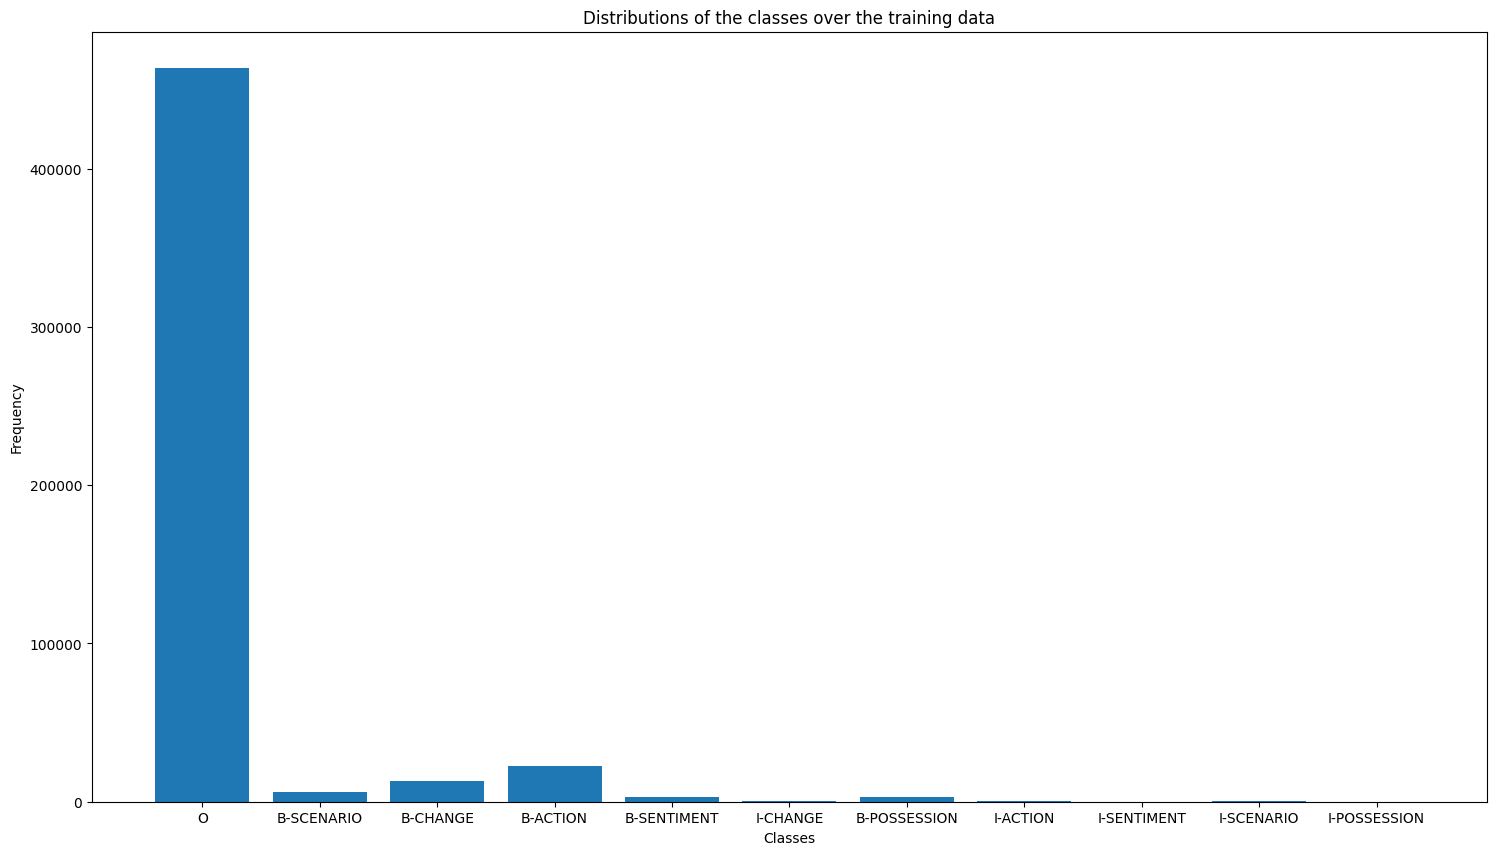

In [ ]:
#plot the classes distribution over the training set

class_counts = Counter()
for sentence in train_data:
    class_counts.update(sentence["labels"])

plt.figure(figsize=(18, 10))
plt.bar(class_counts.keys(), class_counts.values())

plt.title('Distributions of the classes over the training data')
plt.xlabel('Classes')
plt.ylabel('Frequency')


plt.show()


In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
# initialize vocabulary from word to index
vocabulary = {PAD_TOKEN: 0, UNK_TOKEN: 1}
# iterate over the tokens of the dataset, in order to fill the vocabulary
for token in [token.lower() for sentence in train_data for token in sentence["tokens"]]:
  if token not in vocabulary:
    vocabulary[token] = len(vocabulary)

label_vocabulary = {PAD_TOKEN: 0}
for label in [label for sentence in train_data for label in sentence["labels"]]:
  if label not in label_vocabulary:
    label_vocabulary[label] = len(label_vocabulary)

pos_vocabulary = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for sentence in train_data:
    tag_list = nltk.pos_tag(sentence["tokens"])
    print(tag_list)
    for token in tag_list:
        pos = token[1]
        print(pos)
        if pos not in pos_vocabulary:
            pos_vocabulary[pos] = len(pos_vocabulary)

print("Word to Index:")
print(vocabulary)

print("Label to Index:")
print(label_vocabulary)

print("Pos to Index:")
print(pos_vocabulary)

#save vocabularies in binary files through pickle:

with open("/content/drive/MyDrive/nlp2023-hw1/model/vocabulary.pickle", "wb") as file:
    pickle.dump(vocabulary, file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/label_vocabulary.pickle", "wb") as file:
    pickle.dump(label_vocabulary, file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/pos_vocabulary.pickle", "wb") as file:
    pickle.dump(pos_vocabulary, file)

Output streaming troncato alle ultime 5000 righe.
RB
VBN
.
[('In', 'IN'), ('order', 'NN'), ('to', 'TO'), ('attack', 'VB'), ('Damietta', 'NNP'), ('in', 'IN'), ('Egypt', 'NNP'), (',', ','), ('they', 'PRP'), ('allied', 'VBD'), ('in', 'IN'), ('Anatolia', 'NNP'), ('with', 'IN'), ('the', 'DT'), ('Seljuk', 'NNP'), ('Sultanate', 'NNP'), ('of', 'IN'), ('Rûm', 'NNP'), ('which', 'WDT'), ('attacked', 'VBD'), ('the', 'DT'), ('Ayyubids', 'NNP'), ('in', 'IN'), ('Syria', 'NNP'), ('in', 'IN'), ('an', 'DT'), ('attempt', 'NN'), ('to', 'TO'), ('free', 'VB'), ('the', 'DT'), ('Crusaders', 'NNPS'), ('from', 'IN'), ('fighting', 'VBG'), ('on', 'IN'), ('two', 'CD'), ('fronts', 'NNS'), ('.', '.')]
IN
NN
TO
VB
NNP
IN
NNP
,
PRP
VBD
IN
NNP
IN
DT
NNP
NNP
IN
NNP
WDT
VBD
DT
NNP
IN
NNP
IN
DT
NN
TO
VB
DT
NNPS
IN
VBG
IN
CD
NNS
.
[('This', 'DT'), ('will', 'MD'), ('was', 'VBD'), ('later', 'RB'), ('confirmed', 'VBN'), ('at', 'IN'), ('Sariñena', 'NNP'), ('on', 'IN'), ('4', 'CD'), ('September', 'NNP'), ('1134', 'CD'), ('.', '

In [ ]:
class EventDetectionDataset(Dataset):
    def __init__(self, data):
        super().__init__()
        self.data = data

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index]

# **RETRIEVE DATASETS AND VOCABULARIES FROM BINARY FILES**
For faster executions, all the useful variables saved in binary pickle files ==> execute this cell instead of "CREATION of DATASET and VOCABULARIES" after the first creation!

In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

#load data and vocabularies from binary files through pickle:
with open("/content/drive/MyDrive/nlp2023-hw1/model/train_data.pickle", "rb") as file:
    train_data = pickle.load(file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/dev_data.pickle", "rb") as file:
    dev_data = pickle.load(file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/test_data.pickle", "rb") as file:
    test_data = pickle.load(file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/vocabulary.pickle", "rb") as file:
    vocabulary = pickle.load(file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/label_vocabulary.pickle", "rb") as file:
    label_vocabulary = pickle.load(file)

with open("/content/drive/MyDrive/nlp2023-hw1/model/pos_vocabulary.pickle", "rb") as file:
    pos_vocabulary = pickle.load(file)

In [ ]:
class EventDetectionDataset(Dataset):
    def __init__(self, data):
        super().__init__()
        self.data = data

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index]

# **DOWNLOAD WORD EMBEDDINGS**
**!!!EXECUTE ONLY ONE TIME!!!** These cells save 8 possible word embeddings from gensim.models in binary files.

In [ ]:
glove_50 = gensim.downloader.load('glove-wiki-gigaword-50')

with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-50.pickle", "wb") as file:
    pickle.dump(glove_50, file)

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
glove_100 = gensim.downloader.load('glove-wiki-gigaword-100')

with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-100.pickle", "wb") as file:
    pickle.dump(glove_100, file)

In [ ]:
glove_200 = gensim.downloader.load('glove-wiki-gigaword-200')

with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-200.pickle", "wb") as file:
    pickle.dump(glove_200, file)

[==================================================] 100.0% 252.1/252.1MB downloaded


In [ ]:
glove_300 = gensim.downloader.load('glove-wiki-gigaword-300')

with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-300.pickle", "wb") as file:
    pickle.dump(glove_300, file)

In [ ]:
fasttext = gensim.downloader.load('fasttext-wiki-news-subwords-300')

with open("/content/drive/MyDrive/nlp2023-hw1/model/fasttext-wiki-news-subwords-300.pickle", "wb") as file:
    pickle.dump(fasttext, file)

[=================================================-] 100.0% 958.3/958.4MB downloaded


In [ ]:
conceptnet = gensim.downloader.load('conceptnet-numberbatch-17-06-300')

with open("/content/drive/MyDrive/nlp2023-hw1/model/conceptnet-numberbatch-17-06-300.pickle", "wb") as file:
    pickle.dump(conceptnet, file)

[=================================================-] 99.9% 1168.0/1168.7MB downloaded


In [ ]:
w2v_ruscorpora_300 = gensim.downloader.load('word2vec-ruscorpora-300')

with open("/content/drive/MyDrive/nlp2023-hw1/model/word2vec-ruscorpora-300.pickle", "wb") as file:
    pickle.dump(w2v_ruscorpora_300, file)

[==================================================] 100.0% 198.8/198.8MB downloaded


In [ ]:
w2v_300 = gensim.downloader.load('word2vec-google-news-300')

with open("/content/drive/MyDrive/nlp2023-hw1/model/word2vec-google-news-300.pickle", "wb") as file:
    pickle.dump(w2v_300, file)

# **LOAD WORD EMBEDDINGS**
Choose one of the 8 possible word embeddings, execute its cell which loads the weights from a pickle file and sets the embedding dimension.

Glove 50:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-50.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 50
word_embedding_name = "glove-wiki-gigaword-50"

Glove 100:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-100.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 100
word_embedding_name = "glove-wiki-gigaword-100"

Glove 200:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-200.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 200
word_embedding_name = "glove-wiki-gigaword-200"

Glove 300:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/glove-wiki-gigaword-300.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 300
word_embedding_name = "glove-wiki-gigaword-300"

Fasttext:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/fasttext-wiki-news-subwords-300.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 300
word_embedding_name = "fasttext-wiki-news-subwords-300"

Conceptnet:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/conceptnet-numberbatch-17-06-300.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 300
word_embedding_name = "conceptnet-numberbatch-17-06-300"

Word2Vec ruscorpora 300:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/word2vec-ruscorpora-300.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 300
word_embedding_name = "word2vec-ruscorpora-300"

Word2Vec 300:

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/word2vec-google-news-300.pickle", "rb") as file:
    word_embeddings = pickle.load(file)
word_embedding_dim = 300
word_embedding_name = "word2vec-google-news-300"

# **MODEL-TRAINER CLASSES**
**CHOOSE AND EXECUTE ONLY ONE OF THESE CELLS BELOW**

# **MODEL-TRAINER CLASSES (with only WORD embeddings)**

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

from numpy.lib.arraypad import pad
#method that adds paddding to sequences and returns tensors dictionary
def prepare_batch(batch: List[Dict]) -> List[Dict]:
  # extract features and labels from batch
  x = [sentence["tokens"] for sentence in batch]
  y = [sentence["labels"] for sentence in batch]

  # convert tokens to index 
  x = [[vocabulary.get(token, vocabulary[UNK_TOKEN]) for token in sentence] for sentence in x]
  # convert labels to index
  y = [[label_vocabulary[label] for label in sentence] for sentence in y]

  # convert features to tensor and pad them
  x = pad_sequence(
    [torch.as_tensor(sentence) for sentence in x],
    batch_first=True,
    padding_value=vocabulary[PAD_TOKEN]
  )
  # convert and pad labels too
  y = pad_sequence(
    [torch.as_tensor(sentence) for sentence in y],
    batch_first=True,
    padding_value=label_vocabulary[PAD_TOKEN]
  )
  return {"x": x, "y": y}

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

def load_torch_embedding_layer(weights: KeyedVectors, padding_idx: int = 0, freeze: bool = False):
  vectors = weights.vectors
  # random vector for pad
  pad = np.random.rand(1, vectors.shape[1])
  print(pad.shape)
  # mean vector for unknowns
  unk = np.mean(vectors, axis=0, keepdims=True)
  print(unk.shape)
  # concatenate pad and unk vectors on top of pre-trained weights
  vectors = np.concatenate((pad, unk, vectors))
  # convert to pytorch tensor
  vectors = torch.FloatTensor(vectors)
  # and return the embedding layer
  return torch.nn.Embedding.from_pretrained(vectors, padding_idx=padding_idx, freeze=freeze)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionModel(nn.Module):
  
    def __init__(self, hparams, word_weights):
        super(EventDetectionModel, self).__init__()

        self.word_embedding = load_torch_embedding_layer(word_weights)

        self.lstm = nn.LSTM(hparams["word_embedding_dim"], hparams["hidden_dim"], 
                            bidirectional=hparams["bidirectional"],
                            num_layers=hparams["num_layers"], 
                            dropout = hparams["dropout"] if hparams["num_layers"] > 1 else 0)
        
        lstm_output_dim = hparams["hidden_dim"] if hparams["bidirectional"] is False else hparams["hidden_dim"] * 2

        self.dropout = nn.Dropout(hparams["dropout"])
        self.classifier = nn.Linear(lstm_output_dim, hparams["num_classes"])

    
    def forward(self, x):
        embeddings = self.word_embedding(x)
        embeddings = self.dropout(embeddings)
        o, (h, c) = self.lstm(embeddings)
        o = self.dropout(o)
        output = self.classifier(o)
        return output

        

In [ ]:
index_to_label_vocab = {
               0:'O', 
               1:'O', 
               2:'B-SCENARIO', 
               3:'B-CHANGE', 
               4:'B-ACTION', 
               5:'B-SENTIMENT', 
               6:'I-CHANGE', 
               7:'B-POSSESSION', 
               8:'I-ACTION', 
               9:'I-SENTIMENT', 
               10:'I-SCENARIO', 
               11:'I-POSSESSION'
               }

with open("/content/drive/MyDrive/nlp2023-hw1/model/index_to_label_vocab.pickle", "wb") as file:
    pickle.dump(index_to_label_vocab, file)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionTrainer():
    """Utility class to train and evaluate a model."""

    def __init__(
        self,
        model: nn.Module,
        loss_function,
        optimizer,
        device,
        num_classes,
        label_vocab: Dict):
      
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.device = device

        self.label_vocab = label_vocab
        self.num_classes = num_classes

        self.train_loss_list = []
        self.valid_loss_list = []
        self.valid_f1_list = []
        self.best_valid_f1 = 0
        self.best_valid_epoch = 0

        self.history = {}

    def train(self, train_dataloader:DataLoader, 
              valid_dataloader:DataLoader, 
              epochs:int=1):
      
        assert epochs > 1 and isinstance(epochs, int)
        
        print('Training ...')
        
        train_total_batches = len(train_dataloader) # number of batches in the training set

        train_loss = 0.0

        for epoch in range(epochs):
            
            print(' Epoch {:03d}'.format(epoch))

            epoch_loss = 0.0
            self.model.train()

            # for each batch 
            for batch in train_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)
                self.optimizer.zero_grad()

                predictions = self.model(inputs.long())

                predictions = predictions.view(-1, predictions.shape[-1])
                labels = labels.view(-1)

                sample_loss = self.loss_function(predictions, labels)

                sample_loss.backward()
                self.optimizer.step()

                epoch_loss += sample_loss.tolist()
            
            avg_epoch_loss = epoch_loss / train_total_batches
            train_loss += avg_epoch_loss

            print('\t[E: {:2d}] train loss = {:0.4f}'.format(epoch, avg_epoch_loss))
            
            valid_loss, valid_f1 = self.evaluate(valid_dataloader)
            
            print('\t[E: {:2d}] valid loss = {:0.4f}, valid f1 = {:0.4f}\n'.format(epoch, valid_loss, valid_f1))

            self.train_loss_list.append(avg_epoch_loss)
            self.valid_loss_list.append(valid_loss)
            self.valid_f1_list.append(valid_f1)

            #for now, if we obtain a higher F1-Score in Validation Phase, we save the model state in the model.pth file (then, below it could be also saved as best_model if has an higher test_f1_score)
            if valid_f1 > self.best_valid_f1:
              print("\t!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH {:3d}!!! Before = {:0.4f} ===> Now: {:0.4f}\n".format(epoch, self.best_valid_f1, valid_f1))
              torch.save(self.model.state_dict(), "/content/drive/MyDrive/nlp2023-hw1/model/model.pth")
              self.best_valid_f1 = valid_f1
              self.best_valid_epoch = epoch

        print('... Done!')
        
        self.history["train_loss_list"] = self.train_loss_list
        self.history["valid_loss_list"] = self.valid_loss_list
        self.history["valid_f1_list"] = self.valid_f1_list
        self.history["best_valid_f1"] = self.best_valid_f1
        self.history["best_valid_epoch"] = self.best_valid_epoch
        
        avg_epoch_loss = train_loss / epochs
        return avg_epoch_loss
    

    def evaluate(self, valid_dataloader):

        valid_loss = 0.0
        # set dropout to 0!! Needed when we are in inference mode.

        total_predictions = []
        total_labels = []

        self.model.eval()
        with torch.no_grad():
            for batch in valid_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)

                #compute predictions probability distributions (BATCH_SIZE, SEQ_LEN, NUM_CLASSES)
                predictions = self.model(inputs.long())
                #append to total predictions and labels the batch values computed in index format, in order to compute f1 score with seqeval function
                label_list = labels.tolist()
                total_labels.extend(label_list)
                predictions_index = torch.argmax(predictions, -1) #compute predictions as indexes by taking the index of the highest prob => now predictions = (BATCH_SIZE, SEQ_LEN)
                prediction_list = predictions_index.tolist()
                total_predictions.extend(prediction_list)

                predictions = predictions.view(-1, predictions.shape[-1])
                labels = labels.view(-1)
                sample_loss = self.loss_function(predictions, labels)
                valid_loss += sample_loss.tolist()
        
        valid_loss = valid_loss / len(valid_dataloader)

        total_predictions_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_predictions]
        total_labels_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_labels]

        valid_f1 = f1_score(total_labels_tokens, total_predictions_tokens, average="macro", mode="strict", scheme=IOB2)

        return valid_loss, valid_f1

    def predict(self, x, best_model = None):
      
        if best_model==None:
          self.model.eval()
        else:
          best_model.eval()

        with torch.no_grad():
            logits = self.model(x) if best_model==None else best_model(x)
            predictions = torch.argmax(logits, -1)
            return predictions
    
    


# **MODEL-TRAINER CLASSES (with WORD+POS embeddings)**

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

from numpy.lib.arraypad import pad
#method that adds paddding to sequences and returns tensors dictionary
def prepare_batch(batch: List[Dict]) -> List[Dict]:
  # extract features and labels from batch
  x = [sentence["tokens"] for sentence in batch]
  y = [sentence["labels"] for sentence in batch]
  
  pos = []
  #obtain pos tags
  for sentence in x:
      sentence_tags = nltk.pos_tag(sentence)
      sentence_pos_tags = [token[1] for token in sentence_tags]
      pos.append(sentence_pos_tags)

  # convert tokens to index 
  x = [[vocabulary.get(token.lower(), vocabulary[UNK_TOKEN]) for token in sentence] for sentence in x]
  # convert labels to index
  y = [[label_vocabulary[label] for label in sentence] for sentence in y]
  # convert pos_tags to index
  pos = [[pos_vocabulary.get(token, pos_vocabulary[UNK_TOKEN]) for token in sentence] for sentence in pos]

  # convert features to tensor and pad them
  x = pad_sequence(
    [torch.as_tensor(sentence) for sentence in x],
    batch_first=True,
    padding_value=vocabulary[PAD_TOKEN]
  )
  # convert and pad labels too
  y = pad_sequence(
    [torch.as_tensor(sentence) for sentence in y],
    batch_first=True,
    padding_value=label_vocabulary[PAD_TOKEN]
  )
  # convert and pad pos_tags too
  pos = pad_sequence(
    [torch.as_tensor(sentence) for sentence in pos],
    batch_first=True,
    padding_value=pos_vocabulary[PAD_TOKEN]
  )
  
  return {"x": x, "y": y, "pos": pos}

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

def load_torch_embedding_layer(weights: KeyedVectors, padding_idx: int = 0, freeze: bool = False):
  vectors = weights.vectors
  # random vector for pad
  pad = np.random.rand(1, vectors.shape[1])
  print(pad.shape)
  # mean vector for unknowns
  unk = np.mean(vectors, axis=0, keepdims=True)
  print(unk.shape)
  # concatenate pad and unk vectors on top of pre-trained weights
  vectors = np.concatenate((pad, unk, vectors))
  # convert to pytorch tensor
  vectors = torch.FloatTensor(vectors)
  # and return the embedding layer
  return torch.nn.Embedding.from_pretrained(vectors, padding_idx=padding_idx, freeze=freeze)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionModel(nn.Module):
  
    def __init__(self, hparams, word_weights):
        super(EventDetectionModel, self).__init__()

        #Word embeddings
        self.word_embedding = load_torch_embedding_layer(word_weights)

        # POS embeddings
        self.pos_embedding = nn.Embedding(hparams["pos_embedding_dim"], hparams["word_embedding_dim"])

        self.lstm = nn.LSTM(hparams["word_embedding_dim"]*2, hparams["hidden_dim"], 
                            bidirectional=hparams["bidirectional"],
                            num_layers=hparams["num_layers"], 
                            dropout = hparams["dropout"] if hparams["num_layers"] > 1 else 0)
        
        lstm_output_dim = hparams["hidden_dim"] if hparams["bidirectional"] is False else hparams["hidden_dim"] * 2

        self.dropout = nn.Dropout(hparams["dropout"])
        self.classifier = nn.Linear(lstm_output_dim, hparams["num_classes"])

    
    def forward(self, x, pos):
        embeddings = self.word_embedding(x)
        pos_embeddings = self.pos_embedding(pos)
        # concatenate the two embeddings
        embeddings = torch.cat((embeddings, pos_embeddings), dim=2)
        embeddings = self.dropout(embeddings)
        o, (h, c) = self.lstm(embeddings)
        o = self.dropout(o)
        output = self.classifier(o)
        return output



        

In [ ]:
index_to_label_vocab = {
               0:'O', 
               1:'O', 
               2:'B-SCENARIO', 
               3:'B-CHANGE', 
               4:'B-ACTION', 
               5:'B-SENTIMENT', 
               6:'I-CHANGE', 
               7:'B-POSSESSION', 
               8:'I-ACTION', 
               9:'I-SENTIMENT', 
               10:'I-SCENARIO', 
               11:'I-POSSESSION'
               }

with open("/content/drive/MyDrive/nlp2023-hw1/model/index_to_label_vocab.pickle", "wb") as file:
    pickle.dump(index_to_label_vocab, file)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionTrainer():

    def __init__(
        self,
        model: nn.Module,
        loss_function,
        optimizer,
        device,
        num_classes,
        label_vocab: Dict):
      
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.device = device

        self.label_vocab = label_vocab
        self.num_classes = num_classes

        self.train_loss_list = []
        self.valid_loss_list = []
        self.valid_f1_list = []
        self.best_valid_f1 = 0
        self.best_valid_epoch = 0

        self.history = {}

    def train(self, train_dataloader:DataLoader, 
              valid_dataloader:DataLoader, 
              epochs:int=1):
      
        assert epochs > 1 and isinstance(epochs, int)
        
        print('Training ...')
        
        train_total_batches = len(train_dataloader) # number of batches in the training set

        train_loss = 0.0

        for epoch in range(epochs):
            
            print(' Epoch {:03d}'.format(epoch))

            epoch_loss = 0.0
            self.model.train()

            # for each batch 
            for batch in train_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)
                pos_tags = batch["pos"].to(self.device)
                self.optimizer.zero_grad()

                predictions = self.model(inputs.long(), pos_tags.long())

                predictions = predictions.view(-1, predictions.shape[-1])
                labels = labels.view(-1)

                sample_loss = self.loss_function(predictions, labels)

                sample_loss.backward()
                self.optimizer.step()

                epoch_loss += sample_loss.tolist()
            
            avg_epoch_loss = epoch_loss / train_total_batches
            train_loss += avg_epoch_loss

            print('\t[E: {:2d}] train loss = {:0.4f}'.format(epoch, avg_epoch_loss))
            
            valid_loss, valid_f1 = self.evaluate(valid_dataloader)
            
            print('\t[E: {:2d}] valid loss = {:0.4f}, valid f1 = {:0.4f}\n'.format(epoch, valid_loss, valid_f1))

            self.train_loss_list.append(avg_epoch_loss)
            self.valid_loss_list.append(valid_loss)
            self.valid_f1_list.append(valid_f1)

            #for now, if we obtain a higher F1-Score in Validation Phase, we save the model state in the model.pth file (then, below it could be also saved as best_model if has an higher test_f1_score)
            if valid_f1 > self.best_valid_f1:
              print("\t!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH {:3d}!!! Before = {:0.4f} ===> Now: {:0.4f}\n".format(epoch, self.best_valid_f1, valid_f1))
              torch.save(self.model.state_dict(), "/content/drive/MyDrive/nlp2023-hw1/model/model.pth")
              self.best_valid_f1 = valid_f1
              self.best_valid_epoch = epoch

        print('... Done!')
        
        self.history["train_loss_list"] = self.train_loss_list
        self.history["valid_loss_list"] = self.valid_loss_list
        self.history["valid_f1_list"] = self.valid_f1_list
        self.history["best_valid_f1"] = self.best_valid_f1
        self.history["best_valid_epoch"] = self.best_valid_epoch
        
        avg_epoch_loss = train_loss / epochs
        return avg_epoch_loss
    

    def evaluate(self, valid_dataloader):

        valid_loss = 0.0
        # set dropout to 0!! Needed when we are in inference mode.

        total_predictions = []
        total_labels = []

        self.model.eval()
        with torch.no_grad():
            for batch in valid_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)
                pos_tags = batch["pos"].to(self.device)
                #compute predictions probability distributions (BATCH_SIZE, SEQ_LEN, NUM_CLASSES)
                predictions = self.model(inputs.long(), pos_tags.long())
                #append to total predictions and labels the batch values computed in index format, in order to compute f1 score with seqeval function
                label_list = labels.tolist()
                total_labels.extend(label_list)
                predictions_index = torch.argmax(predictions, -1) #compute predictions as indexes by taking the index of the highest prob => now predictions = (BATCH_SIZE, SEQ_LEN)
                prediction_list = predictions_index.tolist()
                total_predictions.extend(prediction_list)

                predictions = predictions.view(-1, predictions.shape[-1])
                labels = labels.view(-1)
                sample_loss = self.loss_function(predictions, labels)
                valid_loss += sample_loss.tolist()
        
        valid_loss = valid_loss / len(valid_dataloader)

        total_predictions_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_predictions]
        total_labels_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_labels]

        valid_f1 = f1_score(total_labels_tokens, total_predictions_tokens, average="macro", mode="strict", scheme=IOB2)

        return valid_loss, valid_f1

    def predict(self, x, pos, best_model = None):

        if best_model==None:
          self.model.eval()
        else:
          best_model.eval()

        with torch.no_grad():
            logits = self.model(x, pos) if best_model==None else best_model(x, pos)
            predictions = torch.argmax(logits, -1)
            return predictions


# **MODEL-TRAINER CLASSES (with WORD+POS embeddings + CRF)**

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

from numpy.lib.arraypad import pad
#method that adds paddding to sequences and returns tensors dictionary
def prepare_batch(batch: List[Dict]) -> List[Dict]:
  # extract features and labels from batch
  x = [sentence["tokens"] for sentence in batch]
  y = [sentence["labels"] for sentence in batch]
  
  pos = []
  #obtain pos tags
  for sentence in x:
      sentence_tags = nltk.pos_tag(sentence)
      sentence_pos_tags = [token[1] for token in sentence_tags]
      pos.append(sentence_pos_tags)

  # convert tokens to index 
  x = [[vocabulary.get(token, vocabulary[UNK_TOKEN]) for token in sentence] for sentence in x]
  # convert labels to index
  y = [[label_vocabulary[label] for label in sentence] for sentence in y]
  # convert pos_tags to index
  pos = [[pos_vocabulary.get(token, pos_vocabulary[UNK_TOKEN]) for token in sentence] for sentence in pos]

  # convert features to tensor and pad them
  x = pad_sequence(
    [torch.as_tensor(sentence) for sentence in x],
    batch_first=True,
    padding_value=vocabulary[PAD_TOKEN]
  )
  # convert and pad labels too
  y = pad_sequence(
    [torch.as_tensor(sentence) for sentence in y],
    batch_first=True,
    padding_value=label_vocabulary[PAD_TOKEN]
  )
  # convert and pad pos_tags too
  pos = pad_sequence(
    [torch.as_tensor(sentence) for sentence in pos],
    batch_first=True,
    padding_value=pos_vocabulary[PAD_TOKEN]
  )
  
  return {"x": x, "y": y, "pos": pos}

In [ ]:
#code taken from NLP Notebook #8 from 2022 course

def load_torch_embedding_layer(weights: KeyedVectors, padding_idx: int = 0, freeze: bool = False):
  vectors = weights.vectors
  # random vector for pad
  pad = np.random.rand(1, vectors.shape[1])
  print(pad.shape)
  # mean vector for unknowns
  unk = np.mean(vectors, axis=0, keepdims=True)
  print(unk.shape)
  # concatenate pad and unk vectors on top of pre-trained weights
  vectors = np.concatenate((pad, unk, vectors))
  # convert to pytorch tensor
  vectors = torch.FloatTensor(vectors)
  # and return the embedding layer
  return torch.nn.Embedding.from_pretrained(vectors, padding_idx=padding_idx, freeze=freeze)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionModel(nn.Module):

    def __init__(self, hparams, word_weights):
        super(EventDetectionModel, self).__init__()

        #Word embeddings
        self.word_embedding = load_torch_embedding_layer(word_weights)

        # POS embeddings
        self.pos_embedding = nn.Embedding(hparams["pos_embedding_dim"], hparams["word_embedding_dim"])

        self.lstm = nn.LSTM(hparams["word_embedding_dim"]*2, hparams["hidden_dim"], 
                            bidirectional=hparams["bidirectional"],
                            num_layers=hparams["num_layers"], 
                            dropout = hparams["dropout"] if hparams["num_layers"] > 1 else 0)
        
        lstm_output_dim = hparams["hidden_dim"] if hparams["bidirectional"] is False else hparams["hidden_dim"] * 2

        self.dropout = nn.Dropout(hparams["dropout"])

        self.hidden2tag = nn.Linear(lstm_output_dim, hparams["num_classes"]) #takes as input the output of LSTM, computes and returns the emissions of shape (batch_size, seq_len, num_classes)
        self.crf = CRF(hparams["num_classes"]) #useful for computing loss and final predictions from the emissions

    
    def forward(self, x, pos):
        embeddings = self.word_embedding(x)
        pos_embeddings = self.pos_embedding(pos)
        # concatenate the two embeddings
        embeddings = torch.cat((embeddings, pos_embeddings), dim=2)
        embeddings = self.dropout(embeddings)
        o, (h, c) = self.lstm(embeddings)
        o = self.dropout(o)
        #
        emissions = self.hidden2tag(o)
        return emissions
    
    def loss(self, emissions, targets):
        crf_loss = self.crf(emissions, targets, reduction='mean')
        return -crf_loss #here it's negative because CRF returns the Negative-Log-Likelihood as Loss

    def predict(self, emissions):
        pred = self.crf.decode(emissions.transpose(0, 1)) #since the decode returns pred = list of lists with shape (seq_len, batch_size), to return the predictions with the correct shape (batch_size, seq_len), transpose is needed
        return pred
        

In [ ]:
index_to_label_vocab = {
               0:'O', 
               1:'O', 
               2:'B-SCENARIO', 
               3:'B-CHANGE', 
               4:'B-ACTION', 
               5:'B-SENTIMENT', 
               6:'I-CHANGE', 
               7:'B-POSSESSION', 
               8:'I-ACTION', 
               9:'I-SENTIMENT', 
               10:'I-SCENARIO', 
               11:'I-POSSESSION'
               }

with open("/content/drive/MyDrive/nlp2023-hw1/model/index_to_label_vocab.pickle", "wb") as file:
    pickle.dump(index_to_label_vocab, file)

In [ ]:
#code taken from Notebook NLP #4

class EventDetectionTrainer():

    def __init__(
        self,
        model: nn.Module,
        loss_function,
        optimizer,
        device,
        num_classes,
        label_vocab: Dict):
      
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.device = device

        self.label_vocab = label_vocab
        self.num_classes = num_classes

        self.train_loss_list = []
        self.valid_loss_list = []
        self.valid_f1_list = []
        self.best_valid_f1 = 0
        self.best_valid_epoch = 0

        self.history = {}

    def train(self, train_dataloader:DataLoader, 
              valid_dataloader:DataLoader, 
              epochs:int=1):
      
        assert epochs > 1 and isinstance(epochs, int)
        
        print('Training ...')
        
        train_total_batches = len(train_dataloader) # number of batches in the training set

        train_loss = 0.0

        for epoch in range(epochs):
            
            print(' Epoch {:03d}'.format(epoch))

            epoch_loss = 0.0
            self.model.train()

            # for each batch 
            for batch in train_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)
                pos_tags = batch["pos"].to(self.device)

                self.optimizer.zero_grad()

                emissions = self.model(inputs.long(), pos_tags.long())

                sample_loss = self.model.loss(emissions, labels)

                sample_loss.backward()
                self.optimizer.step()

                epoch_loss += sample_loss.tolist()
            
            avg_epoch_loss = epoch_loss / train_total_batches
            train_loss += avg_epoch_loss

            print('\t[E: {:2d}] train loss = {:0.4f}'.format(epoch, avg_epoch_loss))
            
            valid_loss, valid_f1 = self.evaluate(valid_dataloader)
            
            print('\t[E: {:2d}] valid loss = {:0.4f}, valid f1 = {:0.4f}\n'.format(epoch, valid_loss, valid_f1))

            self.train_loss_list.append(avg_epoch_loss)
            self.valid_loss_list.append(valid_loss)
            self.valid_f1_list.append(valid_f1)

            #for now, if we obtain a higher F1-Score in Validation Phase, we save the model state in the model.pth file (then, below it could be also saved as best_model if has an higher test_f1_score)
            if valid_f1 > self.best_valid_f1:
              print("\t!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH {:3d}!!! Before = {:0.4f} ===> Now: {:0.4f}\n".format(epoch, self.best_valid_f1, valid_f1))
              torch.save(self.model.state_dict(), "/content/drive/MyDrive/nlp2023-hw1/model/model.pth")
              self.best_valid_f1 = valid_f1
              self.best_valid_epoch = epoch

        print('... Done!')
        
        self.history["train_loss_list"] = self.train_loss_list
        self.history["valid_loss_list"] = self.valid_loss_list
        self.history["valid_f1_list"] = self.valid_f1_list
        self.history["best_valid_f1"] = self.best_valid_f1
        self.history["best_valid_epoch"] = self.best_valid_epoch
        
        avg_epoch_loss = train_loss / epochs
        return avg_epoch_loss
    

    def evaluate(self, valid_dataloader):

        valid_loss = 0.0
        # set dropout to 0!! Needed when we are in inference mode.

        total_predictions = []
        total_labels = []

        self.model.eval()
        with torch.no_grad():
            for batch in valid_dataloader:
                inputs = batch["x"].to(self.device)
                labels = batch["y"].to(self.device)
                pos_tags = batch["pos"].to(self.device)
                
                emissions = self.model(inputs.long(), pos_tags.long())

                sample_loss = self.model.loss(emissions, labels)
                valid_loss += sample_loss.tolist()
                predictions = self.model.predict(emissions) #list of lists of predictions, with shape (batch_size, seq_len)

                #append to total predictions and labels the batch values computed in index format, in order to compute f1 score with seqeval function
                label_list = labels.tolist()
                total_labels.extend(label_list)
                total_predictions.extend(predictions) 
        
        valid_loss = valid_loss / len(valid_dataloader)

        total_predictions_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_predictions]
        total_labels_tokens = [[index_to_label_vocab[label] for label in sample] for sample in total_labels]

        valid_f1 = f1_score(total_labels_tokens, total_predictions_tokens, average="macro", mode="strict", scheme=IOB2)

        return valid_loss, valid_f1

    def predict(self, x, pos, best_model = None):

        if best_model==None:
          self.model.eval()
        else:
          best_model.eval()

        with torch.no_grad():
            emissions = self.model(x, pos) if best_model==None else best_model(x, pos)
            predictions = self.model.predict(emissions) if best_model==None else best_model.predict(emissions)
            return predictions
    

# **HYPERPARAMETERS**

In [ ]:
params = {
    "test_f1" : 0,
    "vocab_size" : len(vocabulary),
    "num_classes" : len(label_vocabulary),
    "word_embeddings" : word_embedding_name,
    "word_embedding_dim" : word_embedding_dim,
    "pos_embedding_dim" : 50,
    "crf" : False,
    "hidden_dim" : 128,
    "bidirectional" : True,
    "num_layers" : 3,
    "dropout" : 0.5,
    "batch_size" : 128,
    "optimizer" : "Adam",
    "learning_rate" : 0.001,
    "epochs" : 100
}

# **TRAINING and VALIDATING PHASES**

In [ ]:

trainingset = EventDetectionDataset(train_data)
devset = EventDetectionDataset(dev_data)
testset = EventDetectionDataset(test_data)

# data loader parameters
collate_fn = prepare_batch # the function that will prepare the data for the model 

train_dataloader = DataLoader(trainingset, collate_fn=collate_fn, batch_size=params["batch_size"], shuffle=True)
valid_dataloader = DataLoader(devset, collate_fn=collate_fn, batch_size=params["batch_size"], shuffle=False)
test_dataloader = DataLoader(testset, collate_fn=collate_fn, batch_size=params["batch_size"], shuffle=False)

event_detector = EventDetectionModel(params, word_embeddings).to(device)

if params["optimizer"] == "Adam":
  optimizer = optim.Adam(event_detector.parameters(), params["learning_rate"])
elif params["optimizer"] == "Adagrad":
  optimizer = optim.Adagrad(event_detector.parameters(), params["learning_rate"])

(1, 50)
(1, 50)


In [ ]:
trainer = EventDetectionTrainer(
    model = event_detector,
    loss_function = nn.CrossEntropyLoss(ignore_index=vocabulary[PAD_TOKEN]),
    optimizer = optimizer,
    device = device,
    num_classes = params["num_classes"],
    label_vocab=label_vocabulary
)

In [ ]:
trainer.train(train_dataloader, valid_dataloader, params["epochs"])

Training ...
 Epoch 000
	[E:  0] train loss = 0.4993
	[E:  0] valid loss = 0.3266, valid f1 = 0.0000

 Epoch 001
	[E:  1] train loss = 0.3130
	[E:  1] valid loss = 0.2783, valid f1 = 0.0833

	!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH   1!!! Before = 0.0000 ===> Now: 0.0833

 Epoch 002
	[E:  2] train loss = 0.2820
	[E:  2] valid loss = 0.2609, valid f1 = 0.0848

	!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH   2!!! Before = 0.0833 ===> Now: 0.0848

 Epoch 003
	[E:  3] train loss = 0.2684
	[E:  3] valid loss = 0.2545, valid f1 = 0.1403

	!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH   3!!! Before = 0.0848 ===> Now: 0.1403

 Epoch 004
	[E:  4] train loss = 0.2575
	[E:  4] valid loss = 0.2391, valid f1 = 0.1619

	!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH   4!!! Before = 0.1403 ===> Now: 0.1619

 Epoch 005
	[E:  5] train loss = 0.2442
	[E:  5] valid loss = 0.2258, valid f1 = 0.2518

	!!!NEW BEST VALID F1-SCORE REACHED AT EPOCH   5!!! Before = 0.1619 ===> Now: 0.2518

 Epoch 006
	[E:  6] tra

0.15014618258282642


The best validation F1-SCORE, achieved during epoch  80, was: 0.6964




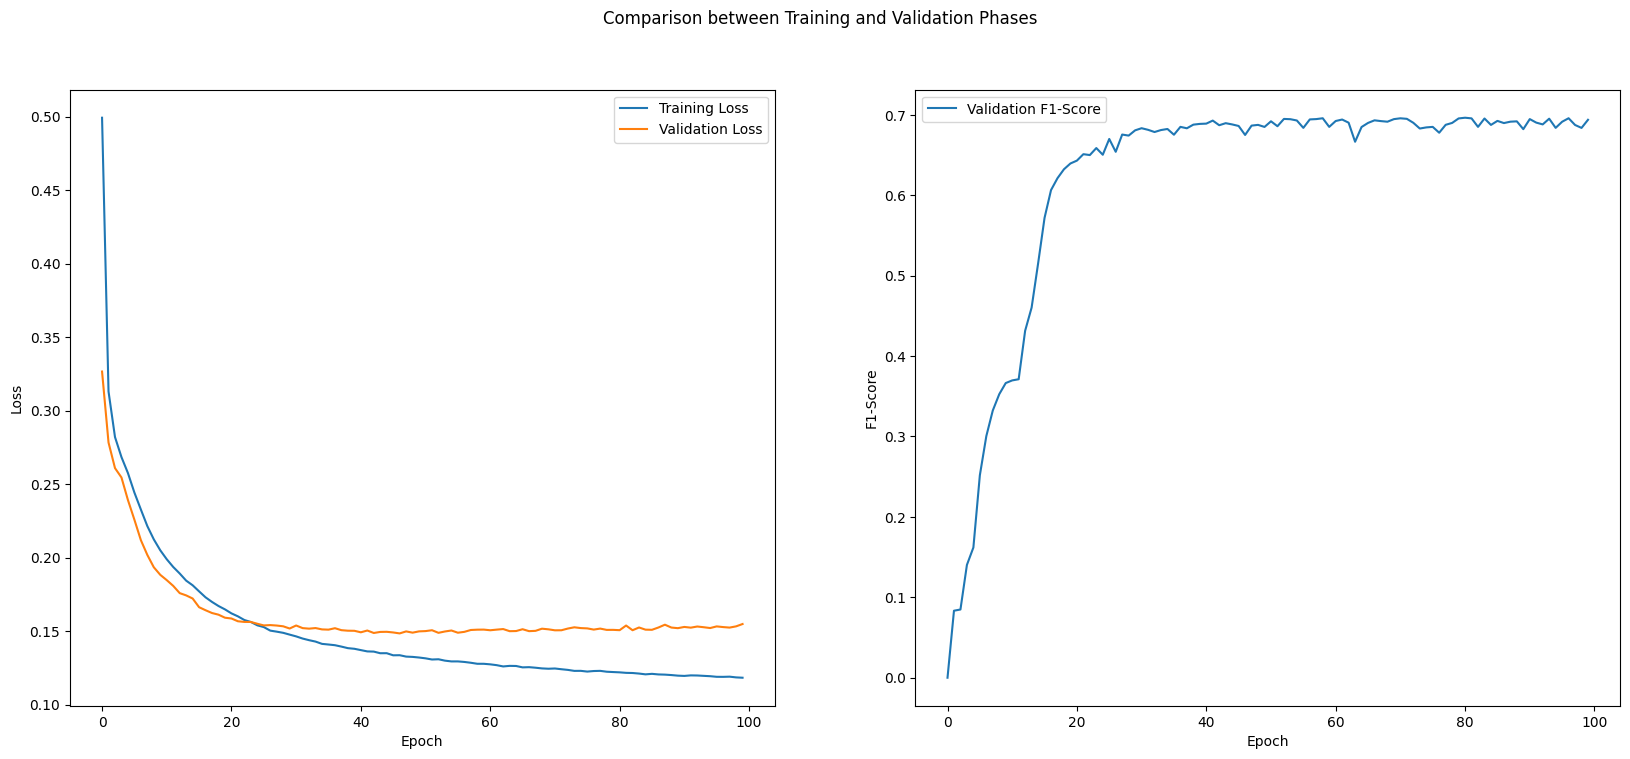

In [ ]:
print("\nThe best validation F1-SCORE, achieved during epoch {:3d}, was: {:0.4f}\n\n".format(trainer.best_valid_epoch, trainer.best_valid_f1))

#Plot Loss-F1_Score progresses over the epochs
epochs = range(0, params["epochs"])
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
axs[0].plot(epochs, trainer.train_loss_list, label='Training Loss')
axs[0].plot(epochs, trainer.valid_loss_list, label='Validation Loss')
axs[1].plot(epochs, trainer.valid_f1_list, label='Validation F1-Score')

fig.suptitle('Comparison between Training and Validation Phases')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('F1-Score')

axs[0].legend()
axs[1].legend()

plt.show()

# **TESTING PHASE (with CURRENT model)**

In [ ]:
def test(test_dataloader, trainer, device, best_model=None, pos = False, crf = False):
  
  #to compute the metrics, we have to return the lists containing the true and predicted labels  
  y_true_total = []
  y_pred_total = []
  
  #call predict
  if pos == True:
    #make predictions with word+pos embeddings model
    for batch in test_dataloader:
        inputs = batch["x"].to(device)
        labels = batch["y"].to(device)
        pos_tags = batch["pos"].to(device)

        predictions = trainer.predict(inputs.long(), pos_tags.long(), best_model)
        
        y_true_total.extend(labels.tolist())
        
        if crf == True:
          #used also CRF
          y_pred_total.extend(predictions) #in case of CRF, the predictions are already a list
        else:
          y_pred_total.extend(predictions.tolist())

  else:
    #only word embeddings
    for batch in test_dataloader:
        inputs = batch["x"].to(device)
        labels = batch["y"].to(device)

        predictions = trainer.predict(inputs.long(), best_model)
        
        y_pred_total.extend(predictions.tolist())
        y_true_total.extend(labels.tolist())

  return y_true_total, y_pred_total

In [ ]:
#this loads the best model obtained in current validation phase
best_model = EventDetectionModel(params, word_embeddings).to(device)

best_model.load_state_dict(torch.load("/content/drive/MyDrive/nlp2023-hw1/model/model.pth"))

is_pos = True if params["pos_embedding_dim"] > 0 else False

y_true_padded, y_pred_padded = test(test_dataloader, trainer, device, best_model, is_pos, params["crf"])

#remove padding elements, by taking for each sentence true/prediction list 
#the sublist with the same length of the corresponding sentence list in the test_data
y_true = []
y_pred = []

for i in range(len(test_data)):
  sen_len= len(test_data[i]["labels"])
  pad_free_y_true = y_true_padded[i][:sen_len]
  pad_free_y_pred = y_pred_padded[i][:sen_len]
  y_true.append(pad_free_y_true)
  y_pred.append(pad_free_y_pred)

print("These are the true labels: \n")
print(y_true)
print("\nThese are the predicted labels: \n")
print(y_pred)

#in order to compute seqeval metrics, first convert  both predicted and true labels into string format
with open("/content/drive/MyDrive/nlp2023-hw1/model/index_to_label_vocab.pickle", "rb") as file:
    index_to_label_vocab = pickle.load(file)

y_true_s = [[index_to_label_vocab[label] for label in sample] for sample in y_true]
y_pred_s = [[index_to_label_vocab[label] for label in sample] for sample in y_pred]

print("\nThese are the true labels in STRING FORMAT: \n")
print(y_true_s)
print("\nThese are the predicted labels in STRING FORMAT: \n")
print(y_pred_s)

#compute scores with seqeval functions
cr = classification_report(y_true_s, y_pred_s, mode='strict', scheme=IOB2)
acc = accuracy_score(y_true_s, y_pred_s)
f = f1_score(y_true_s, y_pred_s, average="macro", mode="strict", scheme=IOB2)

params["test_f1"] = round(f, 4)

print("\n# classification report:\n")
print(f"{cr}")
print(f"# accuracy: {acc:.4f}")
print(f"\n# f1: {f:.4f}")


(1, 50)
(1, 50)
These are the true labels: 

[[1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 3, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1], [1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1], [1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 4, 8, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1], [1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1], [1, 4, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/best_params.pickle", "rb") as file:
    best_params = pickle.load(file)

In [ ]:
#print the best F1-Score as of now (0.7085):
print("The best F1-Score obtained until now is: {:0.4f}".format(best_params["test_f1"]))
print("Now check if it was achieved a new best F1-SCORE....")
#if the new test F1-Score computed in the current session is higher than the best F1-Score, then save state of the model and params
if params["test_f1"] > best_params["test_f1"]:

  print("\n!!! NEW BEST F1-SCORE OBTAINED !!! Its new value is: ", params["test_f1"])
  print("\nNow we save the state of the model and the hyperparameters....")

  NEW_BEST_MODEL_PATH = "/content/drive/MyDrive/nlp2023-hw1/model/model.pth"
  CURRENT_BEST_MODEL_PATH = "/content/drive/MyDrive/nlp2023-hw1/model/best_model.pth"

  new_best_model_state = torch.load(NEW_BEST_MODEL_PATH)

  torch.save(new_best_model_state, CURRENT_BEST_MODEL_PATH)

  with open("/content/drive/MyDrive/nlp2023-hw1/model/best_params.pickle", "wb") as file:
      pickle.dump(params, file)
  with open("/content/drive/MyDrive/nlp2023-hw1/model/best_history.pickle", "wb") as file:
      pickle.dump(trainer.history, file)
  with open("/content/drive/MyDrive/nlp2023-hw1/model/best_trainer.pickle", "wb") as file:
      pickle.dump(trainer, file)

  print("\n....DONE!!!")
else:
  print("\nNOPE. No new best F1-SCORE :( ")

The best F1-Score obtained until now is: 0.7085
Now check if it was achieved a new best F1-SCORE....

NOPE. No new best F1-SCORE :( 


Confusion Matrix:



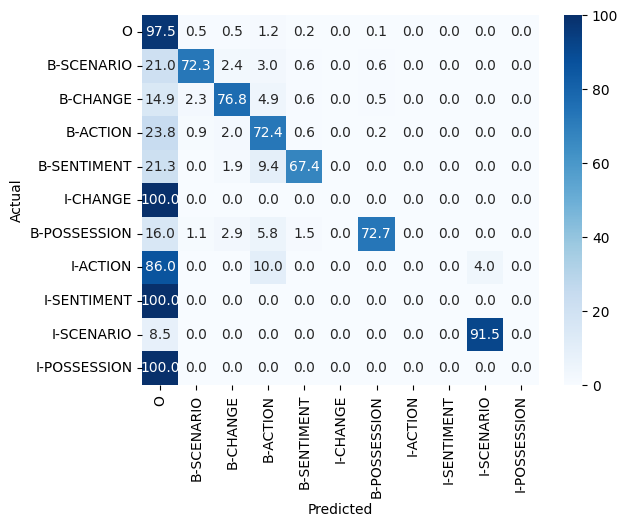

In [ ]:
class_names = ['O', 
               'B-SCENARIO', 
               'B-CHANGE', 
               'B-ACTION', 
               'B-SENTIMENT', 
               'I-CHANGE', 
               'B-POSSESSION', 
               'I-ACTION', 
               'I-SENTIMENT', 
               'I-SCENARIO', 
               'I-POSSESSION']

#to compute confusion matrix, we need to turn the list of lists in a unique list with all the labels
y_true_cm = []
y_pred_cm = []

for sentence in y_true:
  y_true_cm.extend(sentence)

for sentence in y_pred:
  y_pred_cm.extend(sentence)

# Build the confusion matrix
cm = confusion_matrix(y_true_cm, y_pred_cm)
#compute percentages
cm_percentages = cm / cm.sum(axis=1)[:, np.newaxis] * 100
fmt = lambda x: '{:.1f}%'.format(x)

print("Confusion Matrix:\n")
sns.heatmap(cm_percentages, annot=True, fmt=".1f", cmap='Blues', annot_kws={'size':10}, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **TESTING PHASE (with BEST model)**

In [ ]:
def test(test_dataloader, trainer, device, best_model=None, pos = False, crf = False):
  
  #to compute the metrics, we have to return the lists containing the true and predicted labels  
  y_true_total = []
  y_pred_total = []
  
  #call predict
  if pos == True:
    #make predictions with word+pos embeddings model
    for batch in test_dataloader:
        inputs = batch["x"].to(device)
        labels = batch["y"].to(device)
        pos_tags = batch["pos"].to(device)

        predictions = trainer.predict(inputs.long(), pos_tags.long(), best_model)
        
        y_true_total.extend(labels.tolist())
        
        if crf == True:
          #used also CRF
          y_pred_total.extend(predictions) #in case of CRF, the predictions are already a list
        else:
          y_pred_total.extend(predictions.tolist())

  else:
    #only word embeddings
    for batch in test_dataloader:
        inputs = batch["x"].to(device)
        labels = batch["y"].to(device)

        predictions = trainer.predict(inputs.long(), best_model)
        
        y_pred_total.extend(predictions.tolist())
        y_true_total.extend(labels.tolist())

  return y_true_total, y_pred_total

In [ ]:
with open("/content/drive/MyDrive/nlp2023-hw1/model/best_params.pickle", "rb") as file:
    best_params = pickle.load(file)

print("These are the best hyperparameters: \n", best_params)
with open("/content/drive/MyDrive/nlp2023-hw1/model/"+best_params["word_embeddings"]+".pickle", "rb") as file:
    best_word_embeddings = pickle.load(file)

best_model = EventDetectionModel(best_params, best_word_embeddings).to(device)

best_model.load_state_dict(torch.load("/content/drive/MyDrive/nlp2023-hw1/model/best_model.pth"))

with open("/content/drive/MyDrive/nlp2023-hw1/model/best_trainer.pickle", "rb") as file:
    best_trainer = pickle.load(file)

In [ ]:
is_pos = True if best_params["pos_embedding_dim"] > 0 else False

y_true_padded, y_pred_padded = test(test_dataloader, best_trainer, device, best_model, is_pos, best_params["crf"])

#remove padding elements, by taking for each sentence true/prediction list 
#the sublist with the same length of the corresponding sentence list in the test_data
y_true = []
y_pred = []

for i in range(len(test_data)):
  sen_len= len(test_data[i]["labels"])
  pad_free_y_true = y_true_padded[i][:sen_len]
  pad_free_y_pred = y_pred_padded[i][:sen_len]
  y_true.append(pad_free_y_true)
  y_pred.append(pad_free_y_pred)

print("These are the true labels: \n")
print(y_true)
print("\nThese are the predicted labels: \n")
print(y_pred)

#in order to compute seqeval metrics, first convert  both predicted and true labels into string format
with open("/content/drive/MyDrive/nlp2023-hw1/model/index_to_label_vocab.pickle", "rb") as file:
    index_to_label_vocab = pickle.load(file)

y_true_s = [[index_to_label_vocab[label] for label in sample] for sample in y_true]
y_pred_s = [[index_to_label_vocab[label] for label in sample] for sample in y_pred]

print("\nThese are the true labels in STRING FORMAT: \n")
print(y_true_s)
print("\nThese are the predicted labels in STRING FORMAT: \n")
print(y_pred_s)

#compute scores with seqeval functions
cr = classification_report(y_true_s, y_pred_s, mode='strict', scheme=IOB2)
acc = accuracy_score(y_true_s, y_pred_s)
f = f1_score(y_true_s, y_pred_s, average="macro", mode="strict", scheme=IOB2)

print("\n# classification report:\n")
print(f"{cr}")
print(f"# accuracy: {acc:.4f}")
print(f"\n# f1: {f:.4f}")


In [ ]:
class_names = ['O', 
               'B-SCENARIO', 
               'B-CHANGE', 
               'B-ACTION', 
               'B-SENTIMENT', 
               'I-CHANGE', 
               'B-POSSESSION', 
               'I-ACTION', 
               'I-SENTIMENT', 
               'I-SCENARIO', 
               'I-POSSESSION']

#to compute confusion matrix, we need to turn the list of lists in a unique list with all the labels
y_true_cm = []
y_pred_cm = []

for sentence in y_true:
  y_true_cm.extend(sentence)

for sentence in y_pred:
  y_pred_cm.extend(sentence)

# Build the confusion matrix
cm = confusion_matrix(y_true_cm, y_pred_cm)
#compute percentages
cm_percentages = cm / cm.sum(axis=1)[:, np.newaxis] * 100
fmt = lambda x: '{:.1f}%'.format(x)

print("Confusion Matrix:\n")
sns.heatmap(cm_percentages, annot=True, fmt=".1f", cmap='Blues', annot_kws={'size':10}, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()